<a href="https://colab.research.google.com/github/cgm2179/indoor-walk-test/blob/main/Physics%20Engine/2D/SIM%20V3/Indoor%20V3%20Sim/SIM%20V3_Indoor_Phase_BCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SIM V3 · Indoor · Phase B + C + D — one run
Dataset → train → validate → export, top-to-bottom in a **single Colab session on local `/content`** (no per-step Drive reads, so nothing gets lost to async sync). Results are saved to Drive **once**, verified, at the end. Pick a **GPU runtime**.

### 1 · Clone the repo + mount Drive

In [8]:
# /content is wiped on every runtime restart, so (re)clone the code here.
import os, getpass
REPO_ROOT = '/content/indoor-walk-test'
if not os.path.isdir(os.path.join(REPO_ROOT, 'Physics Engine')):
    tok = getpass.getpass('GitHub token (repo read): ')
    os.system(f'git clone --depth 1 https://{tok}@github.com/cgm2179/indoor-walk-test.git "{REPO_ROOT}"')
try:
    from google.colab import drive; drive.mount('/content/drive')   # only for the final save
except ModuleNotFoundError:
    pass
print('repo present:', os.path.isdir(os.path.join(REPO_ROOT, 'Physics Engine', '2D', 'SIM V3')))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
repo present: True


### 2 · Put SIM V3 on the path

In [9]:
import sys, os
SIMV3 = os.path.join(REPO_ROOT, 'Physics Engine', '2D', 'SIM V3')
assert os.path.exists(os.path.join(SIMV3, '_bootstrap.py')), f'clone missing — re-run cell 1: {SIMV3}'
sys.path.insert(0, SIMV3); os.chdir(SIMV3)
import torch; print('SIM V3 =', SIMV3, '| torch', torch.__version__, '| cuda', torch.cuda.is_available())

SIM V3 = /content/indoor-walk-test/Physics Engine/2D/SIM V3 | torch 2.11.0+cu128 | cuda True


### 3 · Parameters (everything local — reliable)

In [10]:
BANDS = ['LTE_B71_617', 'LTE_B13_751', 'LTE_B2_1960', 'NR_n41_2506', 'NR_n77_3700', 'WiFi_2G4', 'WiFi_5G']
SCENE, N_TX, BOXES_PER_FIELD, BOX, N_PER_WAVELENGTH, REGION_M = 'indoor', 6, 80, 128, 8, 40
OUT  = '/content/fw_data_indoor'          # LOCAL disk: fast, reliable, no Drive-sync loss
CKPT = '/content/fw_unet2d_indoor.pt'
EPOCHS, BASE, BS = 80, 32, 16
# (trim BANDS to 1-2 for a quick smoke test; full 7-band gen is ~15 min on GPU)

### 4 · GPU acceleration (CuPy) — FDTD time loop on the GPU

In [11]:
# --- GPU FDTD (CuPy): reuse FullWaveScene setup, run only the time loop on GPU ---
import numpy as np, math
import fw_dataset
from fullwave2d import FullWaveScene

C0 = 299_792_458.0
_cpu_run_field = fw_dataset._run_field          # keep original (fallback + parity check)

USE_GPU = False
try:
    import cupy as cp
    USE_GPU = cp.cuda.runtime.getDeviceCount() > 0
except Exception:
    try:  # Colab GPU runtime usually ships CuPy; install the CUDA-12 wheel if not
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'pip', '-q', 'install', 'cupy-cuda12x'], check=True)
        import cupy as cp
        USE_GPU = cp.cuda.runtime.getDeviceCount() > 0
    except Exception as e:
        print('CuPy unavailable -> staying on CPU:', e)

def _laplacian_gpu(u, inv_h2):                  # matches Spatial_Physics.laplacian (np.roll)
    lap = cp.zeros_like(u)
    for ax in range(u.ndim):
        lap += cp.roll(u, 1, axis=ax) + cp.roll(u, -1, axis=ax)
    lap -= 2.0 * u.ndim * u
    return lap * inv_h2

def _run_field_gpu(classes, h, tx_ij, f_mhz, crossings):
    sim = FullWaveScene(classes, h, f_mhz, tx_ij, source='cw')     # identical CPU setup
    steps = int(round(crossings * max(classes.shape) * h / C0 / sim.dt))
    dt, f0 = sim.dt, sim.f0
    omega = 2.0 * np.pi * f0
    inv_h2 = float(sim.inv_h2)
    u      = cp.asarray(sim.u)                  # move only the fields the loop touches
    u_prev = cp.asarray(sim.u_prev)
    cdt2   = cp.asarray(sim.cdt2)
    inv1pa = cp.asarray(sim._inv1pa)
    _1ma   = cp.asarray(sim._1ma)
    damp   = cp.asarray(sim.damp)
    rigid  = cp.asarray(sim.rigid)
    src    = sim.src_idx
    warmup = int(0.6 * steps)                   # same as _run_field's simulate() call
    period_steps = max(1, int(round((1.0 / f0) / dt)))
    win_start = max(warmup, steps - 2 * period_steps)             # phasor_periods = 2
    acc = cp.zeros(u.shape, cp.complex128); n_win = 0
    for k in range(steps):                      # mirrors FullWaveScene.step() exactly
        lap = _laplacian_gpu(u, inv_h2)
        u_next = (2.0 * u - _1ma * u_prev + cdt2 * lap) * inv1pa
        u_next[src] += math.sin(omega * (k * dt))                # cw() soft source, t=k*dt
        u_next[rigid] = 0.0                     # perfect reflectors
        u_next *= damp                          # absorbing sponge
        u_prev = u * damp
        u = u_next
        if k >= win_start:                      # on-the-fly single-freq DFT (u at (k+1)dt)
            acc += u * complex(np.exp(-1j * omega * (k + 1) * dt))
            n_win += 1
    if not bool(cp.isfinite(u).all()):
        raise FloatingPointError('field blew up (GPU)')
    return cp.asnumpy((2.0 / max(n_win, 1)) * acc)               # complex phasor U, on CPU

if USE_GPU:
    fw_dataset._run_field = _run_field_gpu       # generate() -> _indoor_field -> this
    name = cp.cuda.runtime.getDeviceProperties(0)['name'].decode()
    # parity vs CPU on a tiny field so you can trust the port
    rng = np.random.default_rng(0)
    test = ((rng.random((96, 96)) < 0.12).astype(np.int8) * 2)   # sparse concrete
    Ucpu = _cpu_run_field(test, 0.06, (48, 48), 617.0, 1.2)
    Ugpu = _run_field_gpu(test, 0.06, (48, 48), 617.0, 1.2)
    rel = float(np.abs(Ugpu - Ucpu).max() / (np.abs(Ucpu).max() + 1e-30))
    print(f'GPU FDTD ON -> {name} | parity max|dU|/|U| = {rel:.2e} (want < 1e-6)')
else:
    print('GPU FDTD OFF -> CPU _run_field (pick a GPU runtime for the speed-up).')


GPU FDTD ON -> NVIDIA A100-SXM4-40GB | parity max|dU|/|U| = 0.00e+00 (want < 1e-6)


### 5 · Phase B — generate the dataset (FDTD)

In [12]:
import fw_dataset
fw_dataset.generate(BANDS, scene=SCENE, n_tx=N_TX, boxes_per_field=BOXES_PER_FIELD, box=BOX,
                    n_per_wavelength=N_PER_WAVELENGTH, region_m=REGION_M, out_dir=OUT, seed=1)

  shard 000 indoor LTE_B71_617 tx=(131,64) boxes=80 x(9, 128, 128)
  shard 001 indoor LTE_B71_617 tx=(177,50) boxes=80 x(9, 128, 128)
  shard 002 indoor LTE_B71_617 tx=(235,71) boxes=80 x(9, 128, 128)
  shard 003 indoor LTE_B71_617 tx=(83,75) boxes=80 x(9, 128, 128)
  shard 004 indoor LTE_B71_617 tx=(177,64) boxes=80 x(9, 128, 128)
  shard 005 indoor LTE_B71_617 tx=(176,85) boxes=80 x(9, 128, 128)
  shard 006 indoor LTE_B13_751 tx=(78,80) boxes=80 x(9, 128, 128)
  shard 007 indoor LTE_B13_751 tx=(211,24) boxes=80 x(9, 128, 128)
  shard 008 indoor LTE_B13_751 tx=(78,64) boxes=80 x(9, 128, 128)
  shard 009 indoor LTE_B13_751 tx=(179,38) boxes=80 x(9, 128, 128)
  shard 010 indoor LTE_B13_751 tx=(79,36) boxes=80 x(9, 128, 128)
  shard 011 indoor LTE_B13_751 tx=(51,63) boxes=80 x(9, 128, 128)
  [guard] grid would exceed 1,500,000 cells; dropped cells/wavelength 8 -> 3.0 (h 5.07 cm). Crop for full resolution.
  shard 012 indoor LTE_B2_1960 tx=(176,90) boxes=80 x(9, 128, 128)
  [guard] grid w

PosixPath('/content/fw_data_indoor')

### 6 · Phase C — train the U-Net surrogate (AMP)

In [13]:
import glob, fw_unet2d
print(len(glob.glob(OUT + '/shard_*.npz')), 'shards at', OUT)
model, best = fw_unet2d.train(OUT, epochs=EPOCHS, base=BASE, bs=BS, out=CKPT)
print('best val_mse =', best)

42 shards at /content/fw_data_indoor
device=cuda  cin=9 cout=2  params=7.77M  train=2688 val=672
  mixed precision (AMP fp16): on  batch=16
  ep  0  val_mse=980758027.4637  (best 980758027.4637)
  ep  5  val_mse=980757734.8889  (best 980757734.8889)
  ep 10  val_mse=980757371.7504  (best 980757371.7504)
  ep 15  val_mse=980757624.1418  (best 980757283.1592)
  ep 20  val_mse=980757330.4650  (best 980757247.7062)
  ep 25  val_mse=980757700.3573  (best 980756989.5809)
  ep 30  val_mse=nan  (best 980756989.5809)
  ep 35  val_mse=980767278.0807  (best 980756989.5809)
  ep 40  val_mse=980764595.1622  (best 980756989.5809)
  ep 45  val_mse=980764829.7815  (best 980756989.5809)
  ep 50  val_mse=980762387.2851  (best 980756989.5809)
  ep 55  val_mse=980772472.7177  (best 980756989.5809)
  ep 60  val_mse=980766571.2271  (best 980756989.5809)
  ep 65  val_mse=980787055.5613  (best 980756989.5809)
  ep 70  val_mse=980800348.6009  (best 980756989.5809)
  ep 75  val_mse=980770254.5725  (best 9807569

### 7 · Phase D — g2 validation + ONNX export

In [15]:
!pip -q install onnx onnxruntime
import fw_infer, fw_export
model = fw_unet2d.load_model(CKPT)
print(fw_infer.validate(model, 'LTE_B71_617', seed=99))   # ~3 min: one CPU FDTD vs the surrogate
fw_export.export_onnx(model.cpu(), fw_export.WEB / 'fw_unet2d.onnx'); print('exported', fw_export.WEB / 'fw_unet2d.onnx')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 110.3 MB/s eta 0:00:00


fdtd LTE_B71_617: 100%|██████████| 9150/9150 [02:56<00:00, 51.96step/s]


g2 @ LTE_B71_617  tx=(233,73)  grid (1294, 652)
   envelope dB RMSE = 31.90 dB   Spearman = +0.489   complex coherence = 0.320
   wrote /content/indoor-walk-test/Physics Engine/2D/SIM V3/out/fw_validate/g2_LTE_B71_617.png
{'rmse_db': 31.897653287091227, 'spearman': 0.4894598289621592, 'coherence': 0.3202281962859528}
exported /content/indoor-walk-test/Physics Engine/3D Map Physics/SIM V1 3D/web/fw_unet2d.onnx


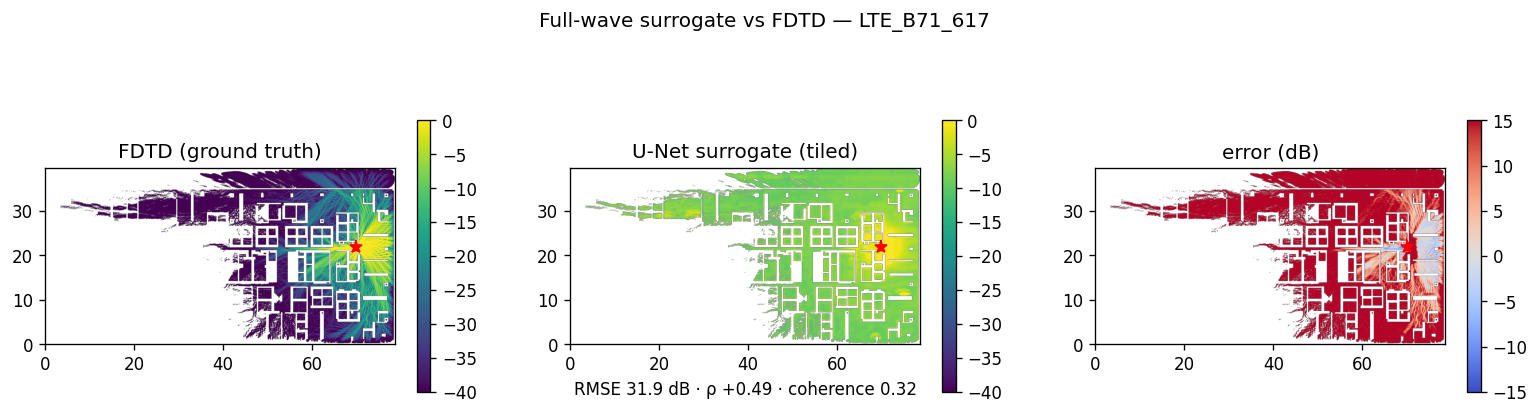

In [16]:
from IPython.display import Image
Image('out/fw_validate/g2_LTE_B71_617.png')

### 8 · Save to Drive — flush + verify (so it can't vanish)

In [17]:
import shutil, glob
from google.colab import drive
shutil.copytree(OUT, '/content/drive/MyDrive/fw_data_indoor', dirs_exist_ok=True)
shutil.copy(CKPT, '/content/drive/MyDrive/fw_unet2d_indoor.pt')
drive.flush_and_unmount(); drive.mount('/content/drive')          # forces the upload to complete
print(len(glob.glob('/content/drive/MyDrive/fw_data_indoor/shard_*.npz')), 'shards on Drive (verified)')

Mounted at /content/drive
42 shards on Drive (verified)


In [19]:
print(fw_export.ort_check(fw_export.WEB / 'fw_unet2d.onnx'))   # -> {'onnxruntime': 'ok', 'out_shape': [1, 2, 128, 128]}

{'onnxruntime': 'ok', 'out_shape': [1, 2, 128, 128]}


In [20]:
# ===== Whole-floor coverage from the trained surrogate, per band (NO FDTD) =====
import numpy as np, json, matplotlib.pyplot as plt
import _bootstrap as B, plane_extract as PE, fw_infer, fw_unet2d
from bands_v3 import get

dev = fw_unet2d.pick_device()
try: model
except NameError: model = fw_unet2d.load_model(CKPT)
model = model.to(dev)                                   # ensure model + inputs share a device

# one Tx (a real AP location), same for every band so they're comparable
man = json.loads(B.MANIFEST.read_text()); cs = float(man['cell_size_m'])
vtx = np.load(B.VALID_TX_MASK); tc = np.argwhere(vtx.any(axis=1))
tx_cell = tc[len(tc)//2]; tx_m = (float(tx_cell[0])*cs, float(tx_cell[1])*cs)

bands = BANDS                                            # from the params cell (all 7)
ncol = min(4, len(bands)); nrow = (len(bands)+ncol-1)//ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2*ncol, 3.6*nrow), squeeze=False)
for ax in axes.flat: ax.axis('off')
for ax, label in zip(axes.flat, bands):
    band = get(label)
    p = PE.extract_plane(band, height_frac=0.5, n_per_wavelength=8.0,
                         tx_m=tx_m, max_cells=1_500_000)                 # resample floor (no FDTD)
    U = fw_infer.tiled_predict(model, p.classes, p.tx_idx, p.h_m, band.f_mhz, dev=dev)  # surrogate: seconds
    env = 20*np.log10(np.abs(U) + 1e-9)
    ax.axis('on')
    im = ax.imshow(env.T, origin='lower', cmap='viridis',
                   extent=[0, p.extent_m[0], 0, p.extent_m[1]],
                   vmin=np.percentile(env, 40), vmax=env.max())
    ax.plot(p.tx_idx[0]*p.h_m, p.tx_idx[1]*p.h_m, 'r*', ms=9)
    ax.set_title(f'{label} · {band.f_mhz:.0f} MHz'); fig.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle('Surrogate whole-floor coverage (no FDTD) — |U| dB', y=1.02)
fig.tight_layout(); plt.show()
fig.savefig('/content/surrogate_coverage.png', dpi=130, bbox_inches='tight')
from google.colab import files; files.download('/content/surrogate_coverage.png')   # or just screenshot the cell

  [guard] grid would exceed 1,500,000 cells; dropped cells/wavelength 8 -> 3.0 (h 5.07 cm). Crop for full resolution.
  [guard] grid would exceed 1,500,000 cells; dropped cells/wavelength 8 -> 2.6 (h 4.66 cm). Crop for full resolution.
  [guard] grid would exceed 1,500,000 cells; dropped cells/wavelength 8 -> 1.6 (h 5.14 cm). Crop for full resolution.
  [guard] grid would exceed 1,500,000 cells; dropped cells/wavelength 8 -> 2.6 (h 4.79 cm). Crop for full resolution.
  [guard] grid would exceed 1,500,000 cells; dropped cells/wavelength 8 -> 1.1 (h 4.79 cm). Crop for full resolution.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
# ===== Tx power & antenna gain on surrogate coverage — post-processing, no re-run =====
import numpy as np, matplotlib.pyplot as plt
import plane_extract as PE, fw_infer
from bands_v3 import get

band = get('WiFi_2G4')                                                 # a Wi-Fi AP
p = PE.extract_plane(band, height_frac=0.5, n_per_wavelength=8.0, tx_m=tx_m, max_cells=1_500_000)
U = fw_infer.tiled_predict(model, p.classes, p.tx_idx, p.h_m, band.f_mhz, dev=dev)   # ONE surrogate pass
rel_db = 20*np.log10(np.abs(U) + 1e-12); rel_db -= rel_db.max()        # relative field, peak = 0 dB
fspl_1m = 20*np.log10(band.f_mhz) - 27.55                             # free-space loss at 1 m

THR = -70                                                            # coverage threshold (dBm)
settings = [(45, 2), (25, 5), (25, 8)]                               # (Tx power dBm, antenna gain dBi)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (pw, g) in zip(axes, settings):
    rsrp = pw + g - fspl_1m + rel_db                                 # EIRP - path loss, all dB
    cov = 100*(rsrp >= THR).mean()
    im = ax.imshow(np.where(rsrp >= THR, rsrp, np.nan).T, origin='lower', cmap='RdYlGn',
                   vmin=THR, vmax=-20, extent=[0, p.extent_m[0], 0, p.extent_m[1]])
    ax.plot(p.tx_idx[0]*p.h_m, p.tx_idx[1]*p.h_m, 'b*', ms=11)
    ax.set_title(f'{pw} dBm + {g} dBi  →  {cov:.0f}% ≥ {THR} dBm')
    fig.colorbar(im, ax=ax, shrink=0.7, label='RSRP dBm')
fig.suptitle(f'{band.label}: one surrogate field, three power/gain settings (instant dB shift)')
fig.tight_layout(); plt.show()
fig.savefig('/content/test_surrogate_coverage.png', dpi=130, bbox_inches='tight')
from google.colab import files; files.download('/content/test_surrogate_coverage.png')   # or just screenshot the cell

  [guard] grid would exceed 1,500,000 cells; dropped cells/wavelength 8 -> 2.6 (h 4.79 cm). Crop for full resolution.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>